⚠️   student-mat.csv not found — generating synthetic data.
     For real results download from UCI and place in /data/


Dataset shape : (395, 33)  (395 students, 33 features)

  DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int32
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int32
 7   Fedu        395 non-null    int32
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int32
 13  studytime   395 non-null    int32
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup

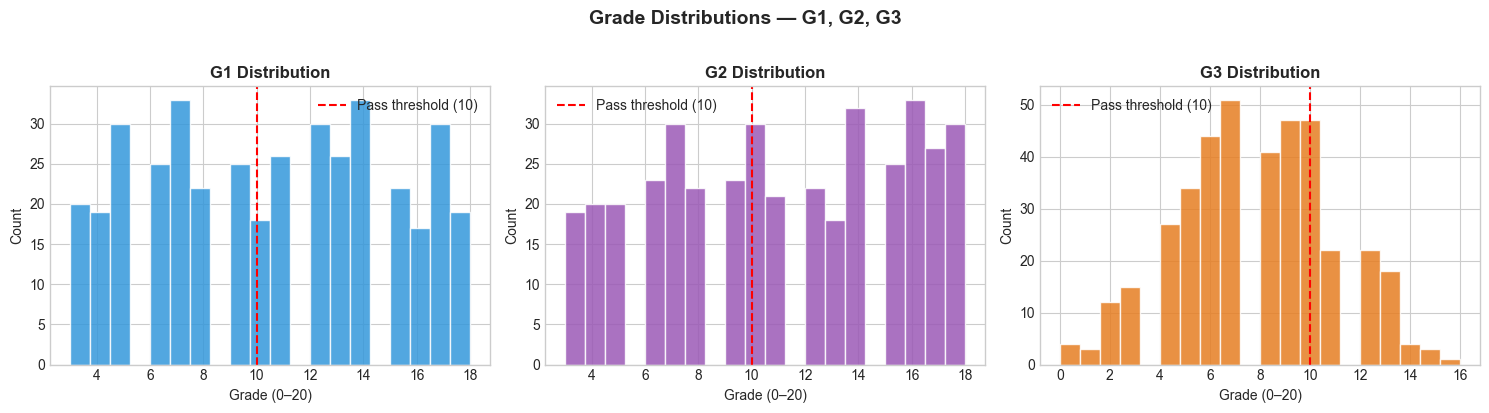

  Plot saved → ../docs/grade_distributions.png

✅  Stage 2 complete.
    Saved : ../data/student_raw.csv
    Next  : python stage3_preprocessing.py


In [1]:
# =============================================================================
# STAGE 2 — Data Collection & Data Understanding
# -----------------------------------------------------------------------------
# Project: Student Performance Prediction & Early Intervention (#23)
# Team   : Abhi | Aparna | Jia  |  Predictive Analytics 2025-26
# Run    : python stage2_data_collection.py
# Output : prints dataset info, statistical summary, feature dictionary
# =============================================================================

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = "../data/student-mat.csv"
DOCS_DIR  = "../docs"
os.makedirs(DOCS_DIR, exist_ok=True)
os.makedirs("../data", exist_ok=True)


# ── 2.1  Load Dataset ─────────────────────────────────────────────────────────
def load_data(path=DATA_PATH):
    """
    Load the UCI Student Performance dataset.
    Download student-mat.csv from:
      https://archive.ics.uci.edu/ml/datasets/student+performance
    Place it in the /data/ folder.
    Falls back to synthetic data for demonstration if the file is missing.
    """
    if os.path.exists(path):
        df = pd.read_csv(path, sep=";")
        print(f"✅  Real UCI dataset loaded from {path}")
    else:
        print("⚠️   student-mat.csv not found — generating synthetic data.")
        print("     For real results download from UCI and place in /data/\n")
        np.random.seed(42)
        n = 395
        df = pd.DataFrame({
            "school"    : np.random.choice(["GP", "MS"], n),
            "sex"       : np.random.choice(["M", "F"], n),
            "age"       : np.random.randint(15, 23, n),
            "address"   : np.random.choice(["U", "R"], n, p=[0.7, 0.3]),
            "famsize"   : np.random.choice(["LE3", "GT3"], n),
            "Pstatus"   : np.random.choice(["T", "A"], n, p=[0.9, 0.1]),
            "Medu"      : np.random.randint(0, 5, n),
            "Fedu"      : np.random.randint(0, 5, n),
            "Mjob"      : np.random.choice(["teacher","health","services",
                                            "at_home","other"], n),
            "Fjob"      : np.random.choice(["teacher","health","services",
                                            "at_home","other"], n),
            "reason"    : np.random.choice(["home","reputation",
                                            "course","other"], n),
            "guardian"  : np.random.choice(["mother","father","other"], n),
            "traveltime": np.random.randint(1, 5, n),
            "studytime" : np.random.randint(1, 4, n),
            "failures"  : np.random.choice([0,1,2,3], n,
                                           p=[0.70,0.15,0.10,0.05]),
            "schoolsup" : np.random.choice(["yes","no"], n),
            "famsup"    : np.random.choice(["yes","no"], n),
            "paid"      : np.random.choice(["yes","no"], n),
            "activities": np.random.choice(["yes","no"], n),
            "nursery"   : np.random.choice(["yes","no"], n),
            "higher"    : np.random.choice(["yes","no"], n, p=[0.85,0.15]),
            "internet"  : np.random.choice(["yes","no"], n, p=[0.80,0.20]),
            "romantic"  : np.random.choice(["yes","no"], n, p=[0.35,0.65]),
            "famrel"    : np.random.randint(1, 6, n),
            "freetime"  : np.random.randint(1, 6, n),
            "goout"     : np.random.randint(1, 6, n),
            "Dalc"      : np.random.randint(1, 6, n),
            "Walc"      : np.random.randint(1, 6, n),
            "health"    : np.random.randint(1, 6, n),
            "absences"  : np.random.randint(0, 40, n),
            "G1"        : np.random.randint(3, 19, n),
            "G2"        : np.random.randint(3, 19, n),
        })
        df["G3"] = np.clip(
            df["G1"]*0.3 + df["G2"]*0.5 + np.random.randint(-3, 3, n),
            0, 20
        ).astype(int)

    print(f"\nDataset shape : {df.shape}  "
          f"({df.shape[0]} students, {df.shape[1]} features)\n")
    return df


# ── 2.2  Basic Info ───────────────────────────────────────────────────────────
def show_basic_info(df):
    print("=" * 50)
    print("  DATASET INFO")
    print("=" * 50)
    df.info()

    print("\n" + "=" * 50)
    print("  STATISTICAL SUMMARY")
    print("=" * 50)
    print(df.describe().round(2).to_string())

    cat_cols = df.select_dtypes(include="object").columns.tolist()
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")
    print(f"Numerical columns  ({len(num_cols)}): {num_cols}")


# ── 2.3  Feature Dictionary ───────────────────────────────────────────────────
def show_feature_dictionary():
    feature_desc = [
        ("school",      "Student school: GP (Gabriel Pereira) or MS"),
        ("sex",         "Student sex: M or F"),
        ("age",         "Age: 15–22"),
        ("address",     "Address: U (Urban) or R (Rural)"),
        ("famsize",     "Family size: LE3 (≤3) or GT3 (>3)"),
        ("Pstatus",     "Parents cohabitation: T (together) or A (apart)"),
        ("Medu",        "Mother education: 0=none … 4=higher"),
        ("Fedu",        "Father education: 0=none … 4=higher"),
        ("Mjob",        "Mother job: teacher/health/services/at_home/other"),
        ("Fjob",        "Father job: teacher/health/services/at_home/other"),
        ("reason",      "School choice reason: home/reputation/course/other"),
        ("guardian",    "Guardian: mother/father/other"),
        ("traveltime",  "Travel time home→school: 1=<15min … 4=>1h"),
        ("studytime",   "Weekly study time: 1=<2h … 4=>10h"),
        ("failures",    "Number of past class failures: 0–3"),
        ("schoolsup",   "Extra school educational support: yes/no"),
        ("famsup",      "Family educational support: yes/no"),
        ("paid",        "Extra paid classes in subject: yes/no"),
        ("activities",  "Extracurricular activities: yes/no"),
        ("nursery",     "Attended nursery school: yes/no"),
        ("higher",      "Wants to take higher education: yes/no"),
        ("internet",    "Internet access at home: yes/no"),
        ("romantic",    "In a romantic relationship: yes/no"),
        ("famrel",      "Family relationship quality: 1=very bad … 5=excellent"),
        ("freetime",    "Free time after school: 1=very low … 5=very high"),
        ("goout",       "Going out with friends: 1=very low … 5=very high"),
        ("Dalc",        "Workday alcohol consumption: 1=very low … 5=very high"),
        ("Walc",        "Weekend alcohol consumption: 1=very low … 5=very high"),
        ("health",      "Health status: 1=very bad … 5=very good"),
        ("absences",    "Number of school absences: 0–93"),
        ("G1",          "First period grade: 0–20"),
        ("G2",          "Second period grade: 0–20"),
        ("G3",          "★ FINAL GRADE: 0–20  →  used to create target variable"),
    ]
    print("\n" + "=" * 65)
    print("  FEATURE DICTIONARY  (33 columns)")
    print("=" * 65)
    print(f"  {'Feature':<12}  Description")
    print("-" * 65)
    for feat, desc in feature_desc:
        print(f"  {feat:<12}  {desc}")
    print()


# ── 2.4  Grade Distribution Plot ─────────────────────────────────────────────
def plot_grade_distributions(df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    colors = ["#3498db", "#9b59b6", "#e67e22"]
    for i, grade in enumerate(["G1", "G2", "G3"]):
        axes[i].hist(df[grade], bins=20, color=colors[i],
                     edgecolor="white", alpha=0.85)
        axes[i].set_title(f"{grade} Distribution",
                          fontsize=12, fontweight="bold")
        axes[i].set_xlabel("Grade (0–20)")
        axes[i].set_ylabel("Count")
        axes[i].axvline(10, color="red", linestyle="--",
                        linewidth=1.5, label="Pass threshold (10)")
        axes[i].legend()
    plt.suptitle("Grade Distributions — G1, G2, G3",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    out = f"{DOCS_DIR}/grade_distributions.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df = load_data()
    show_basic_info(df)
    show_feature_dictionary()
    plot_grade_distributions(df)

    # Save raw dataframe so Stage 3 can load it
    df.to_csv("../data/student_raw.csv", index=False)
    print("\n✅  Stage 2 complete.")
    print("    Saved : ../data/student_raw.csv")
    print("    Next  : python stage3_preprocessing.py")
